In [1]:
import pandas as pd # library for data manipulation and analysis
import numpy as np # library for numerical computations
import seaborn as sns # library for visualization
import os # library for operating system functions
from sklearn.model_selection import train_test_split # library for splitting data into training and testing sets
import tensorflow as tf # library for deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator # library for image data preprocessing
from tensorflow.keras.optimizers import Adam # optimizer for deep learning
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau # callbacks for deep learning training
from tensorflow.keras import layers # layers for building deep learning models
from tensorflow.keras.models import Sequential # library for building deep learning models
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Flatten, Dense, Dropout # layers for building deep learning models
from tensorflow.keras.models import load_model # function for loading a pre-trained model

import warnings # library for suppressing warnings
import matplotlib.pyplot as plt # library for plotting
from glob import glob # library for searching for files

sns.set() # set the plotting style
%matplotlib inline
warnings.filterwarnings("ignore") # ignore warnings

In [2]:
# path to the dataset directory
dataset_path = "data/ArASL_Database_54K_Final"

# path to the label file
label_path = "data/ArSL_Data_Labels.csv"

In [3]:
# get a list of all images in the dataset directory
image = glob(dataset_path + "/*/*.*")

# get the number of images in the list
len(image)

54049

In [4]:
# read the label file into a pandas dataframe
df = pd.read_csv(label_path)

# display the first 5 rows of the dataframe
df.head()

,#,File_Name,Class
0,1,AIN (1).JPG,ain
1,2,AIN (10).JPG,ain
2,3,AIN (100).jpg,ain
3,4,AIN (1000).JPG,ain
4,5,AIN (1001).JPG,ain


In [5]:
# get a list of unique classes in the dataframe
classes = df.Class.unique().tolist()

# print the list of classes
classes

['ain',
 'al',
 'aleff',
 'bb',
 'dal',
 'dha',
 'dhad',
 'fa',
 'gaaf',
 'ghain',
 'ha',
 'haa',
 'jeem',
 'kaaf',
 'khaa',
 'la',
 'laam',
 'meem',
 'nun',
 'ra',
 'saad',
 'seen',
 'sheen',
 'ta',
 'taa',
 'thaa',
 'thal',
 'toot',
 'waw',
 'ya',
 'yaa',
 'zay']

In [6]:
batch_size = 32
img_height = 64
img_width = 64

In [7]:
# create the training and validation datasets
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path, # directory containing the images
  validation_split=0.2, # percentage of data to use for validation
  subset="both", # data to be used for both training and validation
  seed=123, # seed for random number generation
  image_size=(img_height, img_width), # size of the images
  batch_size=batch_size) # batch size for training

Found 54049 files belonging to 32 classes.
Using 43240 files for training.
Using 10809 files for validation.


In [8]:
class_names = train_ds.class_names
print(class_names)

['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']


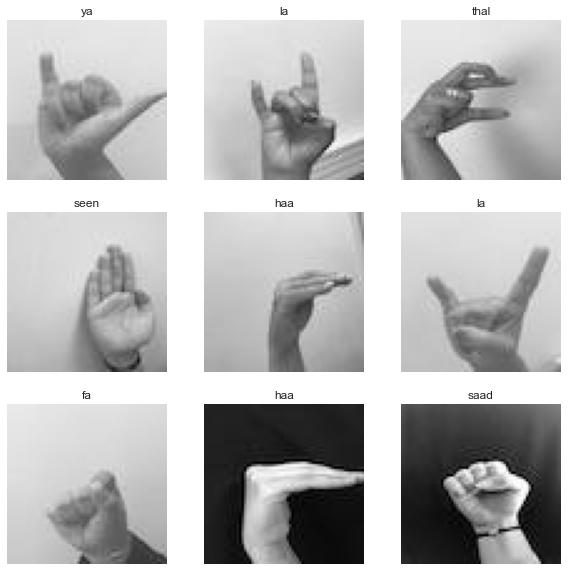

In [9]:
# plot the first 9 images from the training dataset
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
# print the shape of the image batch and labels batch
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 64, 64, 3)
(32,)


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

# cache and shuffle the training dataset and prefetch the data
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# cache and prefetch the validation dataset
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = Sequential([
    # add a RandomFlip layer
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    # add a RandomRotation layer
    layers.RandomRotation(0.1),
    # add a RandomZoom layer
    layers.RandomZoom(0.1)
])

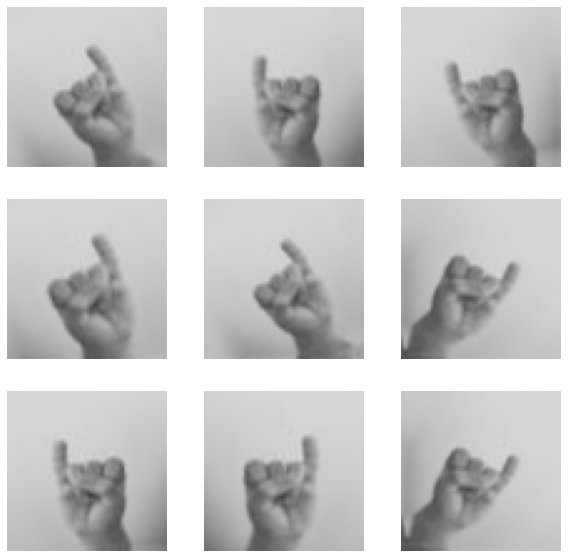

In [13]:
# visualizing 9 augmented images generated from the training dataset.
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

In [59]:
# Define number of classes
num_classes = len(class_names)

# Define the model
model = Sequential([
  # Apply data augmentation
  data_augmentation,
  # Normalize the pixel values
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  # First Conv2D layer with 16 filters and a 3x3 kernel
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  # Max Pooling layer to down-sample the image
  layers.MaxPooling2D(),
  # Second Conv2D layer with 32 filters and a 3x3 kernel
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  # Max Pooling layer to down-sample the image
  layers.MaxPooling2D(),
  # Third Conv2D layer with 64 filters and a 3x3 kernel
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  # Max Pooling layer to down-sample the image
  layers.MaxPooling2D(),
  # Flatten the output of the convolutional layers to feed into a dense layer
  layers.Flatten(),
  # First dense layer with 128 neurons and relu activation
  layers.Dense(128, activation='relu'),
  # Output layer with num_classes neurons and softmax activation
  layers.Dense(num_classes, activation='softmax')
])

In [60]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [61]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 64, 64, 3)         0         
                                                                 
 rescaling_4 (Rescaling)     (None, 64, 64, 3)         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 64, 64, 16)        448       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 32, 32, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 32, 32, 32)        4640      
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 16, 16, 32)       0         
 g2D)                                                 

In [62]:
# Set the file path for saving the model
filepath = "ArSignLang.hdf5"

# Create a ModelCheckpoint to save the model
checkpoint = ModelCheckpoint(
    filepath, 
    
    # Save the entire model, not just the weights
    save_weights_only=False,
    
    # Monitor the validation loss
    monitor='val_loss', 
    
    # Minimize the validation loss
    mode='min', 
    
    # Save only the best model
    save_best_only=True, 
    
    # Show a message when the model is saved
    verbose=1
)

# Create an EarlyStopping callback to stop the training when the validation loss stops improving
earlyStop =  EarlyStopping(
    # Monitor the validation loss
    monitor='val_loss', 
    
    # Minimize the validation loss
    mode='min', 
    
    # Stop the training if the validation loss does not improve for 10 epochs
    patience=10
)

# Combine the callbacks into a list
callbacks_list = [earlyStop, checkpoint]

In [ ]:
epochs=100
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=callbacks_list,
)

Epoch 1/100
1352/1352 [==============================] - ETA: 0s - loss: 1.6887 - accuracy: 0.4947
Epoch 1: val_loss improved from inf to 0.61644, saving model to ArSignLang.hdf5
1352/1352 [==============================] - 65s 46ms/step - loss: 1.6887 - accuracy: 0.4947 - val_loss: 0.6164 - val_accuracy: 0.8055
Epoch 2/100
1351/1352 [============================>.] - ETA: 0s - loss: 0.6206 - accuracy: 0.8090
Epoch 2: val_loss improved from 0.61644 to 0.43546, saving model to ArSignLang.hdf5
1352/1352 [==============================] - 62s 46ms/step - loss: 0.6210 - accuracy: 0.8090 - val_loss: 0.4355 - val_accuracy: 0.8630
Epoch 3/100
1351/1352 [============================>.] - ETA: 0s - loss: 0.3995 - accuracy: 0.8813
Epoch 3: val_loss improved from 0.43546 to 0.29274, saving model to ArSignLang.hdf5
1352/1352 [==============================] - 61s 45ms/step - loss: 0.3994 - accuracy: 0.8813 - val_loss: 0.2927 - val_accuracy: 0.9153
Epoch 4/100
 134/1352 [=>.........................

In [ ]:
# Plot the training loss and validation loss over the epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

In [ ]:
# Plot the training accuracy and validation accuracy over the epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'test'])
plt.show()

In [ ]:
model.load_weights("ArSignLang.hdf5")

loss, accuracy = model.evaluate(train_ds)
print("Training Accuracy:  {:.4f}".format(accuracy))
loss, accuracy = model.evaluate(val_ds)
print("Testing Accuracy:  {:.4f}".format(accuracy))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(val_ds)

predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in val_ds], axis=0)

confusion_mtx = confusion_matrix(predicted_categories, true_categories)

In [ ]:
plt.figure(figsize = (25,25))
sns.heatmap(confusion_mtx,cmap= "Reds", linecolor = 'gray' , linewidth = 0.01 , annot = True, fmt='.2f' , xticklabels = class_names , yticklabels = class_names)
plt.xlabel("predicted label")
plt.ylabel("True Label")
plt.title("confusion matrix")
plt.show()

In [ ]:
print(classification_report(predicted_categories, true_categories,target_names=class_names))

In [ ]:
from PIL import Image
path = r"data/test1.JPG"
im = Image.open(path)
plt.imshow(im)
plt.show()

img = tf.keras.utils.load_img(
    path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)